In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import silhouette_score, confusion_matrix
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [2]:
df = pd.read_csv("../data/heart_disease_cleaned.csv")
X = df.drop("target", axis=1)
y = df["target"]

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

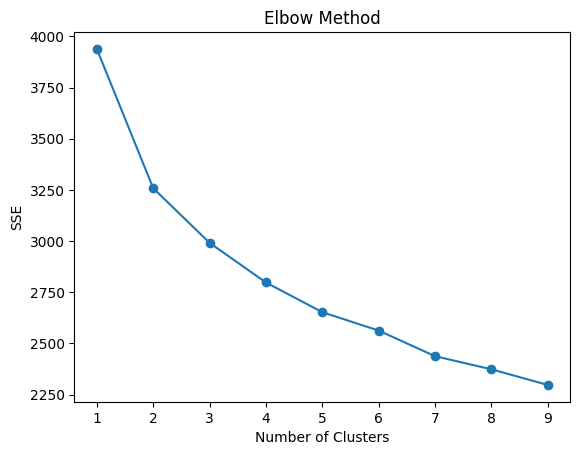

In [4]:
from sklearn.cluster import KMeans

sse = []

for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    sse.append(km.inertia_)

plt.plot(range(1, 10), sse, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.title("Elbow Method")
plt.show()

In [5]:
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Silhouette Score={score:.3f}")

K=2, Silhouette Score=0.173
K=3, Silhouette Score=0.129
K=4, Silhouette Score=0.128
K=5, Silhouette Score=0.114
K=6, Silhouette Score=0.118
K=7, Silhouette Score=0.106
K=8, Silhouette Score=0.105
K=9, Silhouette Score=0.102


In [6]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

In [7]:
print(pd.crosstab(df["Cluster"], df["target"]))

target     0    1
Cluster          
0         12  102
1        152   37


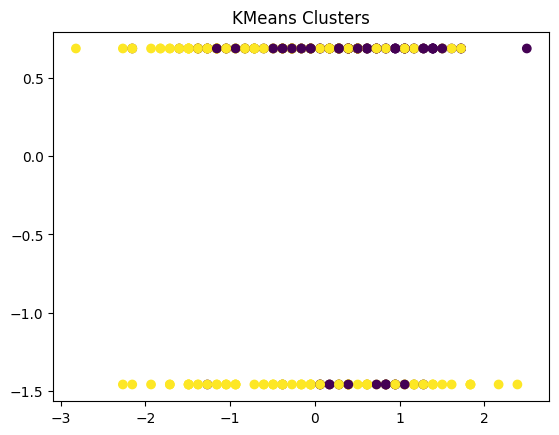

In [8]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=df["Cluster"], cmap="viridis")
plt.title("KMeans Clusters")
plt.show()

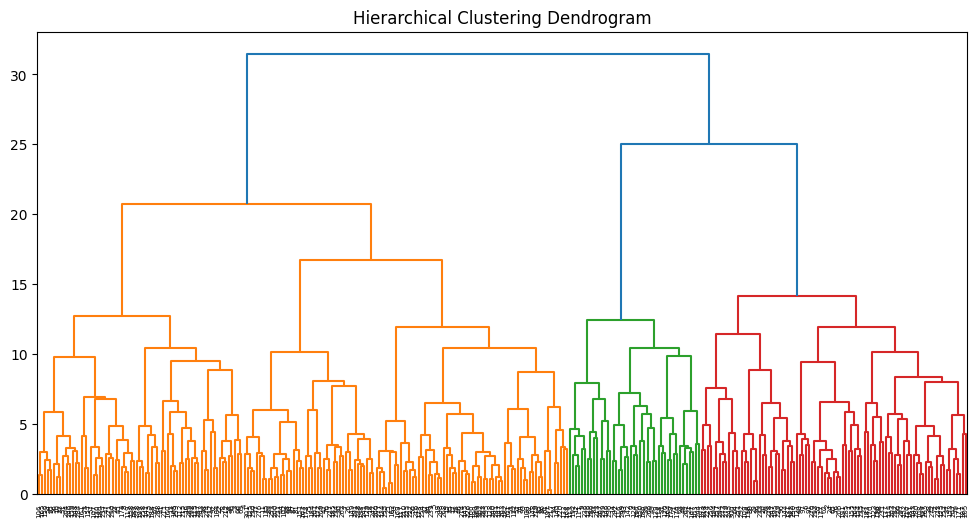

In [9]:
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12,6))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

In [10]:
df["HCluster"] = fcluster(Z, 2, criterion='maxclust')

In [11]:
print(pd.crosstab(df["HCluster"], df["target"]))

target      0   1
HCluster         
1         122  51
2          42  88


1. The elbow method suggests the optimal K value.

2. Silhouette score validates cluster separation.

3. K-Means clusters partially align with actual disease labels.

4. Hierarchical clustering provides a visual understanding of data grouping.

5. Since clustering is unsupervised, perfect alignment with labels is not expected.